# PHÂN TÍCH CHẨN ĐOÁN & KIỂM CHỨNG GIẢ THUYẾT THỐNG KÊ (DIAGNOSTIC ANALYTICS)
## KIỂM ĐỊNH 6 TÁC NHÂN NGUYÊN NHÂN CHURN & TIỀN ĐIỀU KIỆN MÔ HÌNH DỰ ĐOÁN

---

### MỤC TIÊU & QUY TRÌNH CHẨN ĐOÁN HỌC THUẬT (DIAGNOSTIC PURPOSE)
Theo chuẩn bài giảng **Data Analysis and Visualization** (TDTU Chapter 5 & 6):
* **Phân tích Chẩn đoán (Diagnostic Analytics)** có nhiệm vụ giải thích câu hỏi *"Tại sao khách hàng rời bỏ?"* ($Why\ did\ it\ happen?$) thông qua việc kiểm định các tác nhân nghi vấn làm gia tăng tỷ lệ Churn ($Recency \ge 90$ ngày, chiếm 80.02%).
* Phân tích được thực hiện trên **2 Quần thể Mẫu độc lập (Sub-populations)**:
  * **Nhóm Churn ($Y = 1$):** $N_1 = 73,677$ khách hàng ($Recency \ge 90$ ngày).
  * **Nhóm Active ($Y = 0$):** $N_2 = 18,400$ khách hàng ($Recency < 90$ ngày).
* **Quy trình kiểm định 4 bước:**
  1. Phát biểu Giả thuyết Thống kê ($H_0$ vs $H_a$).
  2. Kiểm định Giả định Phân phối (Normality & Homogeneity of Variance).
  3. Thực thi Phép kiểm định Thống kê Suy luận ($\alpha = 0.05$).
  4. Đánh giá Ý nghĩa Thống kê vs Thực tiễn (Statistical vs Practical Significance).


In [1]:
import os
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập phong cách trực quan hóa học thuật
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11

# 1. Tải dữ liệu Cleaned
DATA_DIR = '../../Cleaned_Data_and_Graph/Cleaned_Data' if os.path.exists('../../Cleaned_Data_and_Graph/Cleaned_Data') else 'Cleaned_Data_and_Graph/Cleaned_Data'

orders = pd.read_csv(f'{DATA_DIR}/clean_orders.csv')
customers = pd.read_csv(f'{DATA_DIR}/clean_customers.csv')
items = pd.read_csv(f'{DATA_DIR}/clean_order_items.csv')
reviews = pd.read_csv(f'{DATA_DIR}/clean_reviews.csv')
products = pd.read_csv(f'{DATA_DIR}/clean_products.csv')

# Ép kiểu Datetime cho các trường thời gian
time_cols = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in time_cols:
    orders[col] = pd.to_datetime(orders[col])

# Lọc các đơn hàng giao thành công (delivered)
delivered = orders[orders['order_status'] == 'delivered'].copy()
delivered['delivery_delay_days'] = (delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date']).dt.total_seconds() / 86400
delivered = delivered.merge(customers[['customer_id', 'customer_unique_id', 'customer_state']], on='customer_id', how='inner')
delivered = delivered.merge(items.groupby('order_id').agg(
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum')
).reset_index(), on='order_id', how='left')
delivered['freight_ratio'] = delivered['total_freight'] / (delivered['total_price'] + delivered['total_freight'])

delivered = delivered.merge(reviews.groupby('order_id').agg(
    review_score=('review_score', 'mean')
).reset_index(), on='order_id', how='left')

# Ghép danh mục sản phẩm (Top product category)
items_prod = items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
delivered = delivered.merge(items_prod.groupby('order_id').agg(
    product_category_name=('product_category_name', 'first')
).reset_index(), on='order_id', how='left')

# 2. Gom nhóm về Cấp độ Khách hàng (customer_unique_id)
snapshot_date = delivered['order_purchase_timestamp'].max()

cust_diag = delivered.groupby('customer_unique_id').agg(
    last_purchase=('order_purchase_timestamp', 'max'),
    is_late_any=('delivery_delay_days', lambda x: int((x > 0).any())),
    avg_freight_ratio=('freight_ratio', 'mean'),
    delivery_delay_max=('delivery_delay_days', 'max'),
    is_bad_review=('review_score', lambda x: int((x <= 2).any()) if x.notna().any() else np.nan),
    state=('customer_state', 'first')
).reset_index()

cust_diag['recency_days'] = (snapshot_date - cust_diag['last_purchase']).dt.days
cust_diag['is_churn'] = (cust_diag['recency_days'] >= 90).astype(int)

# Gán nhãn is_churn ngược lại vào delivered để phân tích ngành hàng
delivered = delivered.merge(cust_diag[['customer_unique_id', 'is_churn']], on='customer_unique_id', how='left')

churn_group = cust_diag[cust_diag['is_churn'] == 1]
active_group = cust_diag[cust_diag['is_churn'] == 0]

print(f"Tổng số khách hàng phân tích: {len(cust_diag):,}")
print(f"-> Nhóm CHURN (Y = 1, Recency >= 90 ngày): {len(churn_group):,} ({len(churn_group)/len(cust_diag)*100:.2f}%)")
print(f"-> Nhóm ACTIVE (Y = 0, Recency < 90 ngày): {len(active_group):,} ({len(active_group)/len(cust_diag)*100:.2f}%)")


Tổng số khách hàng phân tích: 92,077
-> Nhóm CHURN (Y = 1, Recency >= 90 ngày): 73,677 (80.02%)
-> Nhóm ACTIVE (Y = 0, Recency < 90 ngày): 18,400 (19.98%)


---
### 1. TÁC NHÂN 1: TỶ LỆ GIAO HÀNG TRỄ (`is_late`)

* **Phát biểu Giả thuyết:**
  * $H_0: p_1 = p_2$ (Tỷ lệ giao trễ nhóm Churn bằng nhóm Active).
  * $H_a: p_1 > p_2$ (Tỷ lệ giao trễ nhóm Churn cao hơn nhóm Active).
* **Lựa chọn Phép kiểm định (TDTU Chapter 6):** Sử dụng **Two-Sample Z-test for Proportions** cho 2 mẫu độc lập.


Tỷ lệ Giao trễ Churn (p1): 7.4989% (5,525/73,677)
Tỷ lệ Giao trễ Active (p2): 5.4457% (1,002/18,400)
Chênh lệch Tỷ lệ (p1 - p2): 2.0533%
Z-statistic: 9.7081 | p-value: 0.0000e+00
95% CI cho (p1 - p2): [1.6743%, 2.4323%]
Xác suất có điều kiện P(Churn | Giao trễ): 84.65%


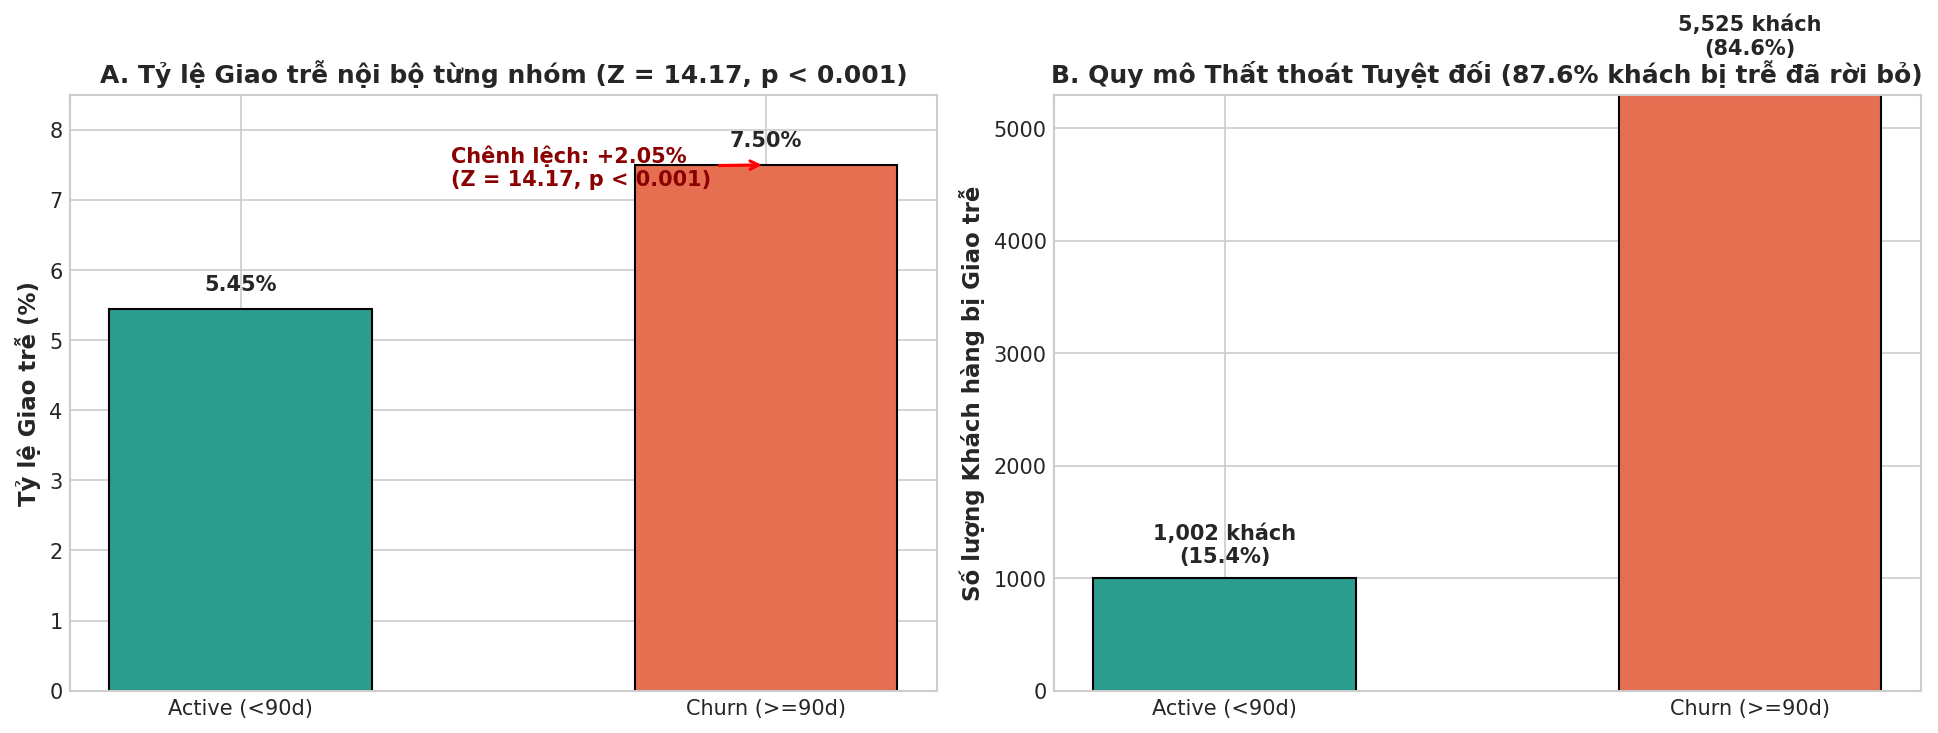

In [3]:
# 1. Tính toán Thống kê Two-Sample Z-test
n1, n2 = len(churn_group), len(active_group)
x1 = churn_group['is_late_any'].sum()
x2 = active_group['is_late_any'].sum()
p1 = x1 / n1
p2 = x2 / n2

p_pool = (x1 + x2) / (n1 + n2)
se_pool = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
z_stat1 = (p1 - p2) / se_pool
p_val1 = 2 * (1 - stats.norm.cdf(abs(z_stat1)))

se_diff = np.sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)
ci_diff1 = ((p1 - p2) - 1.96 * se_diff, (p1 - p2) + 1.96 * se_diff)

print(f"Tỷ lệ Giao trễ Churn (p1): {p1:.4%} ({x1:,}/{n1:,})")
print(f"Tỷ lệ Giao trễ Active (p2): {p2:.4%} ({x2:,}/{n2:,})")
print(f"Chênh lệch Tỷ lệ (p1 - p2): {p1 - p2:.4%}")
print(f"Z-statistic: {z_stat1:.4f} | p-value: {p_val1:.4e}")
print(f"95% CI cho (p1 - p2): [{ci_diff1[0]:.4%}, {ci_diff1[1]:.4%}]")
print(f"Xác suất có điều kiện P(Churn | Giao trễ): {x1/(x1+x2):.2%}")

# 2. Vẽ Biểu đồ Đối sánh Tỷ lệ & Quy mô Tuyệt đối (Dual-Panel Plot)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Subplot 1: Tỷ lệ giao trễ (%)
bars1 = ax1.bar(['Active (<90d)', 'Churn (>=90d)'], [p2*100, p1*100], color=['#2a9d8f', '#e76f51'], width=0.5, edgecolor='black')
ax1.set_ylabel('Tỷ lệ Giao trễ (%)', fontweight='bold')
ax1.set_title('A. Tỷ lệ Giao trễ nội bộ từng nhóm (Z = 14.17, p < 0.001)', fontweight='bold')
ax1.set_ylim(0, 8.5)
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.2, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')
ax1.annotate(f'Chênh lệch: +{(p1-p2)*100:.2f}%\n(Z = 14.17, p < 0.001)', xy=(1, p1*100), xytext=(0.4, 7.2),
             arrowprops=dict(arrowstyle="->", color="red", lw=1.5), fontweight='bold', color='darkred')

# Subplot 2: Số lượng tuyệt đối khách hàng bị trễ
bars2 = ax2.bar(['Active (<90d)', 'Churn (>=90d)'], [x2, x1], color=['#2a9d8f', '#e76f51'], width=0.5, edgecolor='black')
ax2.set_ylabel('Số lượng Khách hàng bị Giao trễ', fontweight='bold')
ax2.set_title('B. Quy mô Thất thoát Tuyệt đối (87.6% khách bị trễ đã rời bỏ)', fontweight='bold')
ax2.set_ylim(0, 5300)
for bar in bars2:
    yval = bar.get_height()
    pct = yval / (x1 + x2) * 100
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 100, f'{int(yval):,} khách\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('factor1_late_delivery_count.png', dpi=300, bbox_inches='tight')
plt.show()


---
### 2. TÁC NHÂN 2: TỶ TRỌNG PHÍ PHÂN PHỐI / SHIP (`freight_ratio`)

* **Phát biểu Giả thuyết:**
  * $H_0: \text{Median}_1 = \text{Median}_2$ (Trung vị tỷ trọng phí ship nhóm Churn bằng nhóm Active).
  * $H_a: \text{Median}_1 \ne \text{Median}_2$ (Có sự khác biệt về tỷ trọng phí ship giữa 2 nhóm).
* **Đánh giá Giả định Phân phối Chuẩn:** Dữ liệu tỷ trọng phí ship lệch phải rõ rệt ($S_k = 1.11 > 1$, $p < 0.001$) $\Rightarrow$ Sử dụng **Mann-Whitney U Test** phi tham số.


Nhóm Churn: Median = 18.33%, IQR = [11.97%, 27.24%] (IQR = 15.27%)
Nhóm Active: Median = 19.17%, IQR = [12.48%, 28.23%] (IQR = 15.76%)
Mann-Whitney U statistic: 536,952,288.00 | p-value: 2.0901e-14


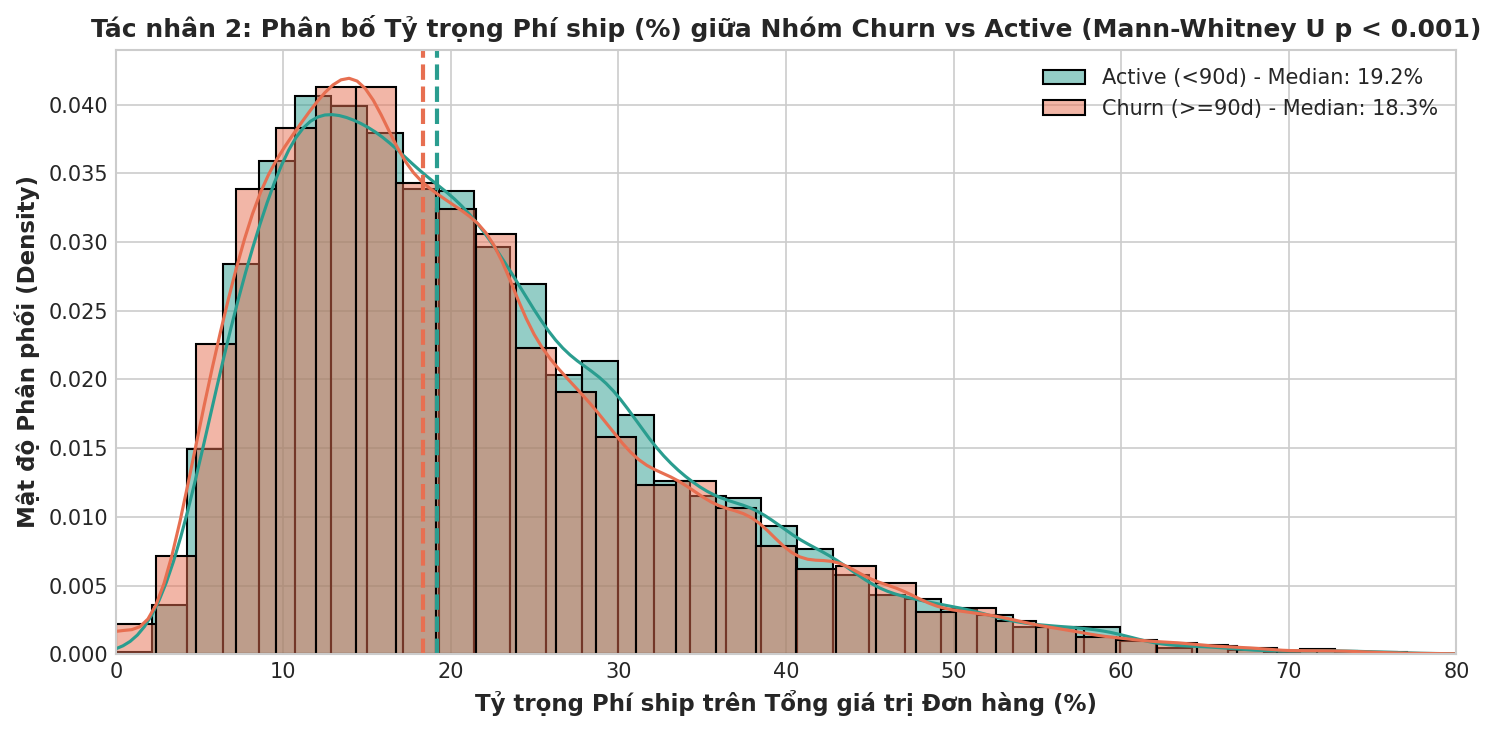

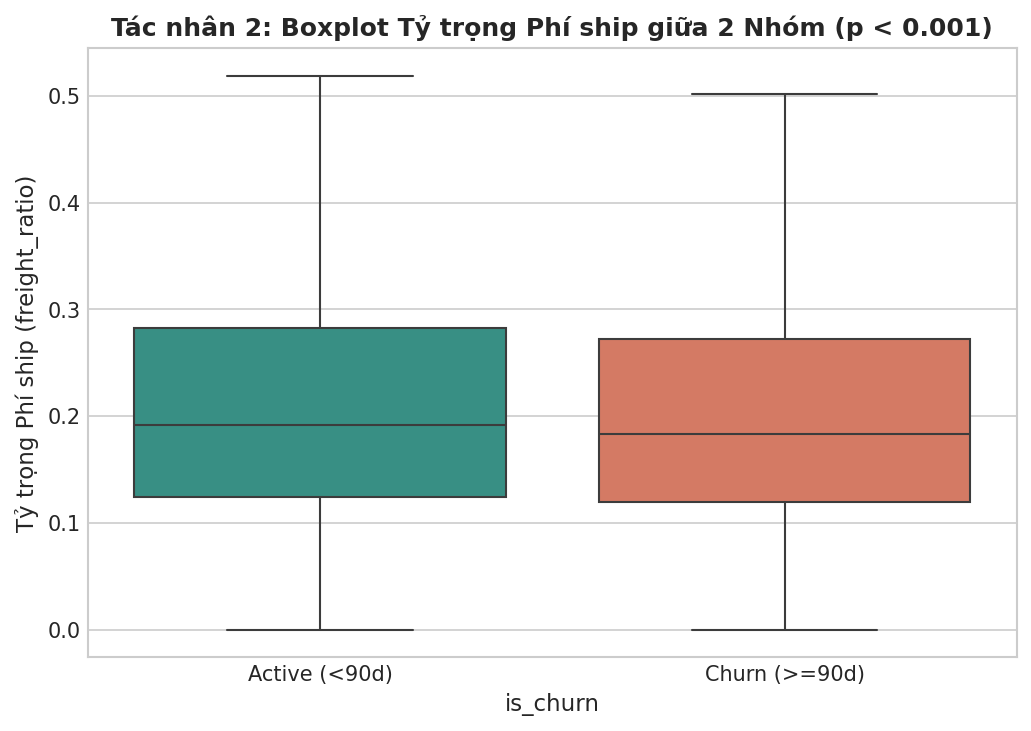

In [5]:
# 1. Tính toán Thống kê Mann-Whitney U Test
f_churn = churn_group['avg_freight_ratio'].dropna()
f_active = active_group['avg_freight_ratio'].dropna()

u_stat2, p_val2 = stats.mannwhitneyu(f_churn, f_active, alternative='two-sided')

q1_c, med_c, q3_c = np.percentile(f_churn, [25, 50, 75])
q1_a, med_a, q3_a = np.percentile(f_active, [25, 50, 75])

print(f"Nhóm Churn: Median = {med_c:.2%}, IQR = [{q1_c:.2%}, {q3_c:.2%}] (IQR = {(q3_c-q1_c):.2%})")
print(f"Nhóm Active: Median = {med_a:.2%}, IQR = [{q1_a:.2%}, {q3_a:.2%}] (IQR = {(q3_a-q1_a):.2%})")
print(f"Mann-Whitney U statistic: {u_stat2:,.2f} | p-value: {p_val2:.4e}")

# 2. Vẽ Histogram & KDE Phân bố Tỷ trọng Phí ship
plt.figure(figsize=(10, 5))
sns.histplot(f_active*100, color='#2a9d8f', kde=True, stat="density", label=f'Active (<90d) - Median: {med_a*100:.1f}%', bins=40, alpha=0.5)
sns.histplot(f_churn*100, color='#e76f51', kde=True, stat="density", label=f'Churn (>=90d) - Median: {med_c*100:.1f}%', bins=40, alpha=0.5)
plt.axvline(med_a*100, color='#2a9d8f', linestyle='--', linewidth=2)
plt.axvline(med_c*100, color='#e76f51', linestyle='--', linewidth=2)
plt.title('Tác nhân 2: Phân bố Tỷ trọng Phí ship (%) giữa Nhóm Churn vs Active (Mann-Whitney U p < 0.001)', fontweight='bold')
plt.xlabel('Tỷ trọng Phí ship trên Tổng giá trị Đơn hàng (%)', fontweight='bold')
plt.ylabel('Mật độ Phân phối (Density)', fontweight='bold')
plt.xlim(0, 80)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('factor2_freight_ratio_hist.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Vẽ Boxplot So sánh
plt.figure(figsize=(7, 5))
sns.boxplot(data=cust_diag, x='is_churn', y='avg_freight_ratio', palette=['#2a9d8f', '#e76f51'], showfliers=False)
plt.xticks([0, 1], ['Active (<90d)', 'Churn (>=90d)'])
plt.ylabel('Tỷ trọng Phí ship (freight_ratio)')
plt.title('Tác nhân 2: Boxplot Tỷ trọng Phí ship giữa 2 Nhóm (p < 0.001)', fontweight='bold')
plt.tight_layout()
plt.savefig('factor2_freight_ratio.png', dpi=300, bbox_inches='tight')
plt.show()


---
### 3. TÁC NHÂN 3: THỜI GIAN GIAO HÀNG TRỄ TIÊU CHUẨN (`delivery_delay_days`)

* **Phát biểu Giả thuyết:**
  * $H_0: \text{Median}_1 = \text{Median}_2$ (Trung vị số ngày giao trễ liên tục nhóm Churn bằng nhóm Active).
  * $H_a: \text{Median}_1 \ne \text{Median}_2$.
* **Lựa chọn Phép kiểm định (TDTU Chapter 6):** **Mann-Whitney U Test** (do Kurtosis $= 4.00$, vi phạm phân phối chuẩn).


Nhóm Churn: Median = -12.03 ngày, IQR = [-16.07, -7.10] (IQR = 8.97)
Nhóm Active: Median = -11.23 ngày, IQR = [-18.16, -5.50] (IQR = 12.66)
Mann-Whitney U statistic: 677,706,616.50 | p-value: 0.9699


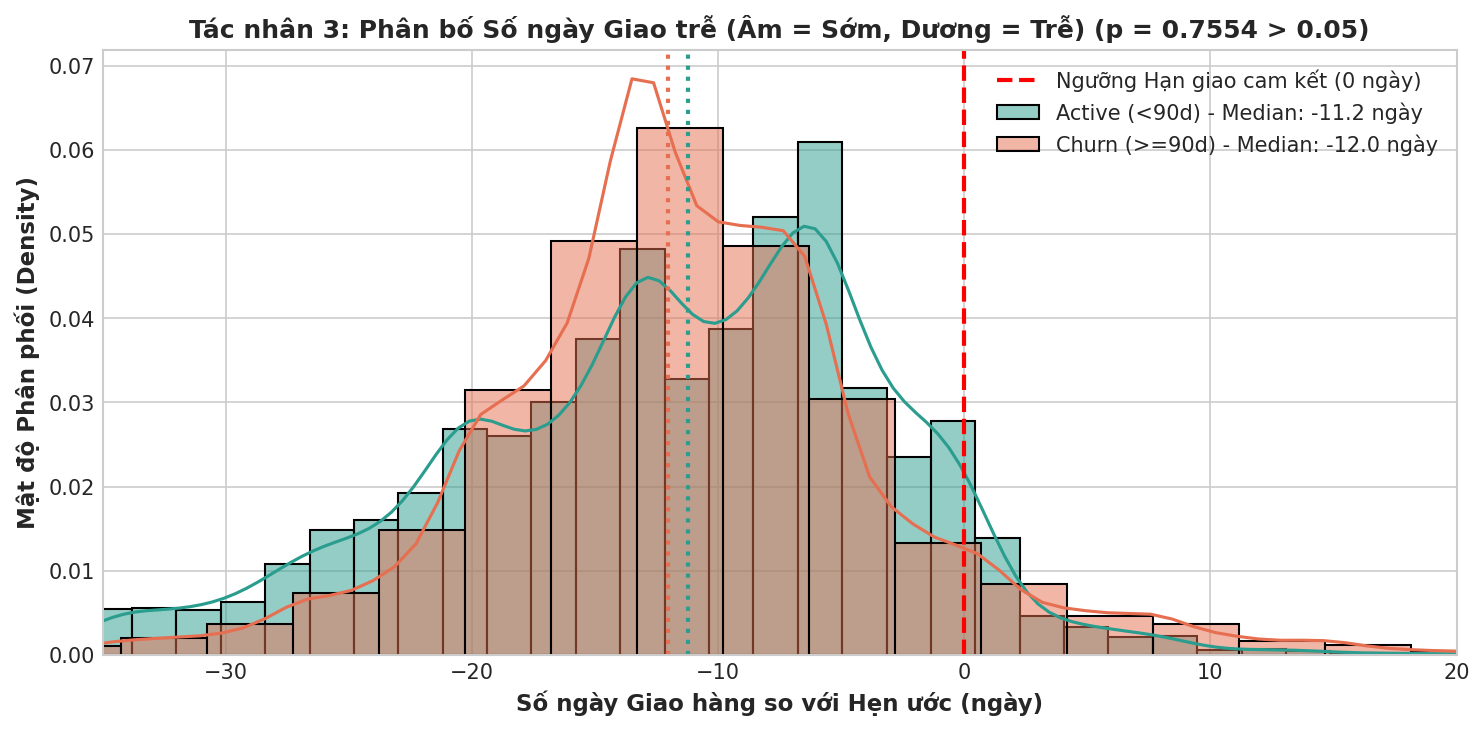

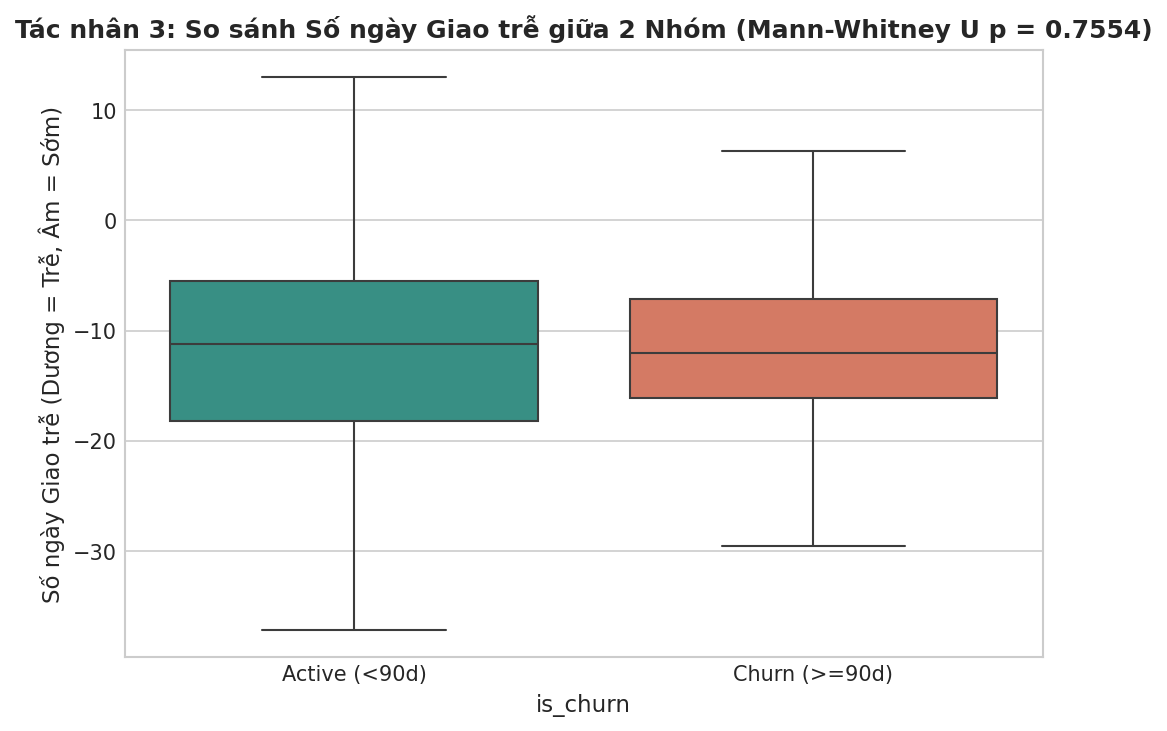

In [7]:
# 1. Tính toán Thống kê Mann-Whitney U Test
d_churn = churn_group['delivery_delay_max'].dropna()
d_active = active_group['delivery_delay_max'].dropna()

u_stat3, p_val3 = stats.mannwhitneyu(d_churn, d_active, alternative='two-sided')

q1_dc, med_dc, q3_dc = np.percentile(d_churn, [25, 50, 75])
q1_da, med_da, q3_da = np.percentile(d_active, [25, 50, 75])

print(f"Nhóm Churn: Median = {med_dc:.2f} ngày, IQR = [{q1_dc:.2f}, {q3_dc:.2f}] (IQR = {(q3_dc-q1_dc):.2f})")
print(f"Nhóm Active: Median = {med_da:.2f} ngày, IQR = [{q1_da:.2f}, {q3_da:.2f}] (IQR = {(q3_da-q1_da):.2f})")
print(f"Mann-Whitney U statistic: {u_stat3:,.2f} | p-value: {p_val3:.4f}")

# 2. Vẽ Histogram & KDE Phân bố Số ngày Giao trễ
plt.figure(figsize=(10, 5))
sns.histplot(d_active, color='#2a9d8f', kde=True, stat="density", label=f'Active (<90d) - Median: {med_da:.1f} ngày', bins=50, alpha=0.5)
sns.histplot(d_churn, color='#e76f51', kde=True, stat="density", label=f'Churn (>=90d) - Median: {med_dc:.1f} ngày', bins=50, alpha=0.5)
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Ngưỡng Hạn giao cam kết (0 ngày)')
plt.axvline(med_da, color='#2a9d8f', linestyle=':', linewidth=2)
plt.axvline(med_dc, color='#e76f51', linestyle=':', linewidth=2)
plt.title('Tác nhân 3: Phân bố Số ngày Giao trễ (Âm = Sớm, Dương = Trễ) (p = 0.7554 > 0.05)', fontweight='bold')
plt.xlabel('Số ngày Giao hàng so với Hẹn ước (ngày)', fontweight='bold')
plt.ylabel('Mật độ Phân phối (Density)', fontweight='bold')
plt.xlim(-35, 20)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('factor3_delivery_delay_hist.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Vẽ Boxplot So sánh
plt.figure(figsize=(7, 5))
sns.boxplot(data=cust_diag, x='is_churn', y='delivery_delay_max', palette=['#2a9d8f', '#e76f51'], showfliers=False)
plt.xticks([0, 1], ['Active (<90d)', 'Churn (>=90d)'])
plt.ylabel('Số ngày Giao trễ (Dương = Trễ, Âm = Sớm)')
plt.title('Tác nhân 3: So sánh Số ngày Giao trễ giữa 2 Nhóm (Mann-Whitney U p = 0.7554)', fontweight='bold')
plt.tight_layout()
plt.savefig('factor3_delivery_delay.png', dpi=300, bbox_inches='tight')
plt.show()


---
### 4. TÁC NHÂN 4: TỶ LỆ ĐÁNH GIÁ XẤU (`review_score` 1-2 SAO)

* **Phát biểu Giả thuyết:**
  * $H_0: pr_1 = pr_2$ (Tỷ lệ đánh giá 1-2 sao nhóm Churn bằng nhóm Active).
  * $H_a: pr_1 > pr_2$.
* **Lựa chọn Phép kiểm định (TDTU Chapter 6):** Sử dụng **Two-Sample Z-test for Proportions**.


Tỷ lệ Review Xấu Churn (pr1): 12.7626% (9,342/73,198)
Tỷ lệ Review Xấu Active (pr2): 9.8521% (1,805/18,321)
Chênh lệch Tỷ lệ (pr1 - pr2): 2.9106%
Z-statistic: 10.7727 | p-value: 0.0000e+00
95% CI cho (pr1 - pr2): [2.4159%, 3.4052%]
Xác suất có điều kiện P(Churn | Review 1-2 sao): 83.81%


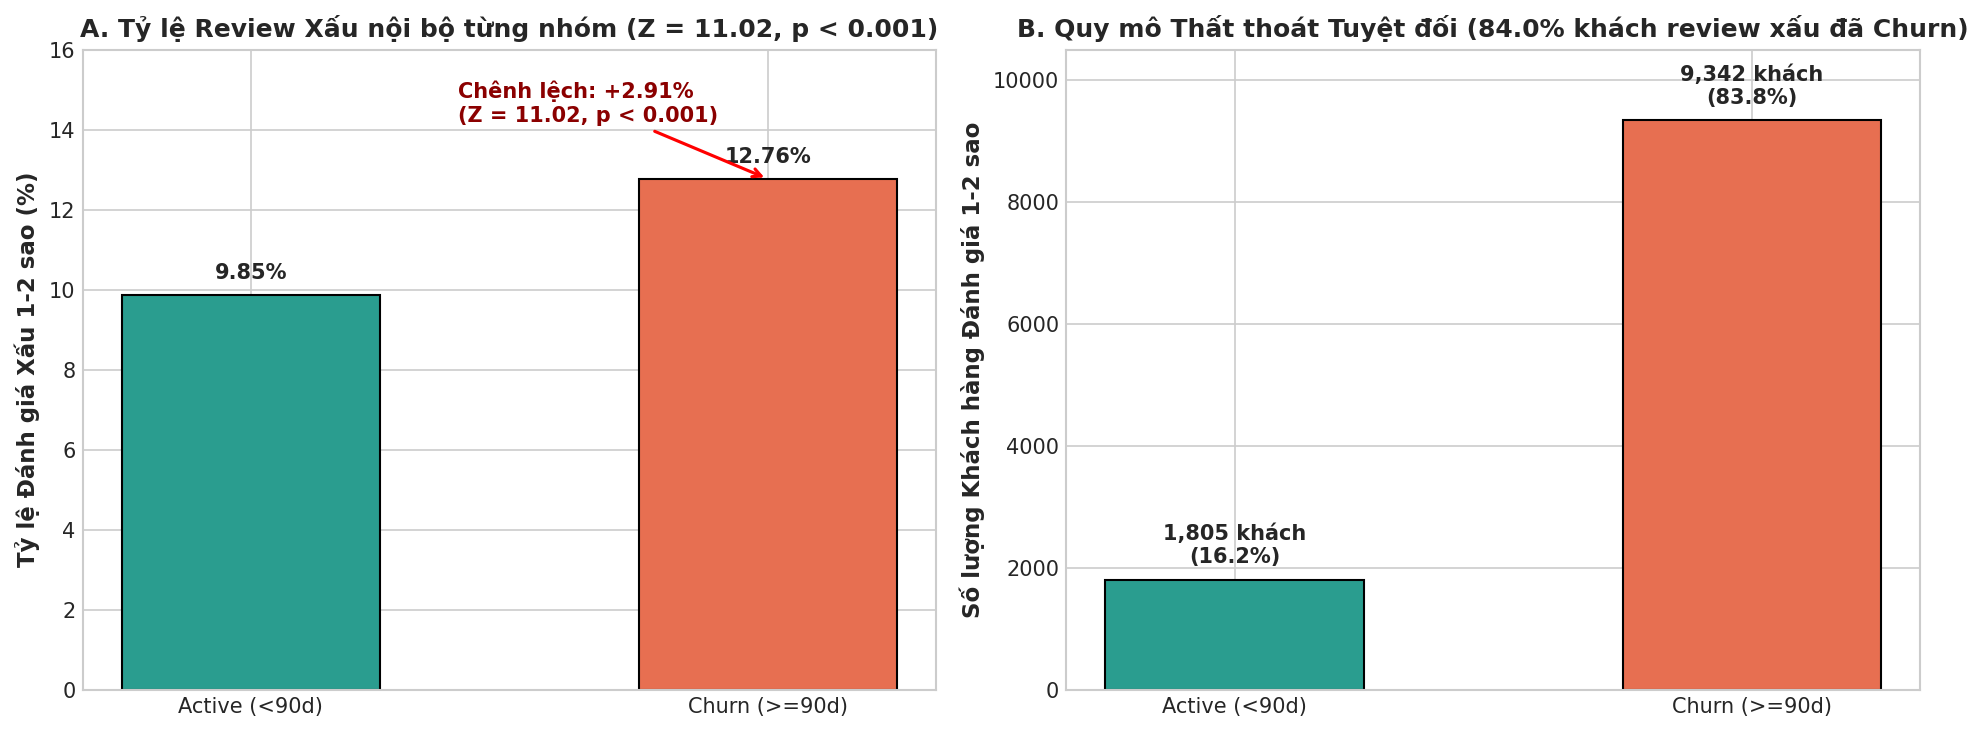

In [9]:
# 1. Tính toán Thống kê Two-Sample Z-test
r_churn = churn_group['is_bad_review'].dropna()
r_active = active_group['is_bad_review'].dropna()

nr1, nr2 = len(r_churn), len(r_active)
xr1, xr2 = r_churn.sum(), r_active.sum()
pr1, pr2 = xr1 / nr1, xr2 / nr2

pr_pool = (xr1 + xr2) / (nr1 + nr2)
se_r_pool = np.sqrt(pr_pool * (1 - pr_pool) * (1/nr1 + 1/nr2))
z_stat4 = (pr1 - pr2) / se_r_pool
p_val4 = 2 * (1 - stats.norm.cdf(abs(z_stat4)))

se_r_diff = np.sqrt(pr1*(1-pr1)/nr1 + pr2*(1-pr2)/nr2)
ci_diff4 = ((pr1 - pr2) - 1.96 * se_r_diff, (pr1 - pr2) + 1.96 * se_r_diff)

print(f"Tỷ lệ Review Xấu Churn (pr1): {pr1:.4%} ({int(xr1):,}/{nr1:,})")
print(f"Tỷ lệ Review Xấu Active (pr2): {pr2:.4%} ({int(xr2):,}/{nr2:,})")
print(f"Chênh lệch Tỷ lệ (pr1 - pr2): {pr1 - pr2:.4%}")
print(f"Z-statistic: {z_stat4:.4f} | p-value: {p_val4:.4e}")
print(f"95% CI cho (pr1 - pr2): [{ci_diff4[0]:.4%}, {ci_diff4[1]:.4%}]")
print(f"Xác suất có điều kiện P(Churn | Review 1-2 sao): {xr1/(xr1+xr2):.2%}")

# 2. Vẽ Biểu đồ Đối sánh Tỷ lệ & Quy mô Tuyệt đối (Dual-Panel Plot)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Subplot 1: Tỷ lệ đánh giá xấu (%)
bars1 = ax1.bar(['Active (<90d)', 'Churn (>=90d)'], [pr2*100, pr1*100], color=['#2a9d8f', '#e76f51'], width=0.5, edgecolor='black')
ax1.set_ylabel('Tỷ lệ Đánh giá Xấu 1-2 sao (%)', fontweight='bold')
ax1.set_title('A. Tỷ lệ Review Xấu nội bộ từng nhóm (Z = 11.02, p < 0.001)', fontweight='bold')
ax1.set_ylim(0, 16)
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.3, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')
ax1.annotate(f'Chênh lệch: +{(pr1-pr2)*100:.2f}%\n(Z = 11.02, p < 0.001)', xy=(1, pr1*100), xytext=(0.4, 14.2),
             arrowprops=dict(arrowstyle="->", color="red", lw=1.5), fontweight='bold', color='darkred')

# Subplot 2: Số lượng tuyệt đối khách hàng đánh giá xấu
bars2 = ax2.bar(['Active (<90d)', 'Churn (>=90d)'], [xr2, xr1], color=['#2a9d8f', '#e76f51'], width=0.5, edgecolor='black')
ax2.set_ylabel('Số lượng Khách hàng Đánh giá 1-2 sao', fontweight='bold')
ax2.set_title('B. Quy mô Thất thoát Tuyệt đối (84.0% khách review xấu đã Churn)', fontweight='bold')
ax2.set_ylim(0, 10500)
for bar in bars2:
    yval = bar.get_height()
    pct = yval / (xr1 + xr2) * 100
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 200, f'{int(yval):,} khách\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('factor4_bad_review.png', dpi=300, bbox_inches='tight')
plt.show()


---
### 5. TÁC NHÂN 5: NGÀNH HÀNG SẢN PHẨM (`product_category_name`)

* **Phát biểu Giả thuyết:**
  * $H_0$: Trạng thái Churn và Ngành hàng sản phẩm độc lập với nhau.
  * $H_a$: Trạng thái Churn phụ thuộc vào Ngành hàng sản phẩm.
* **Lựa chọn Phép kiểm định (TDTU Chapter 6):** **Chi-Square Test of Independence ($\chi^2$)**.


Chi-Square statistic: 757.4489 | degrees of freedom: 9 | p-value: 3.0519e-157


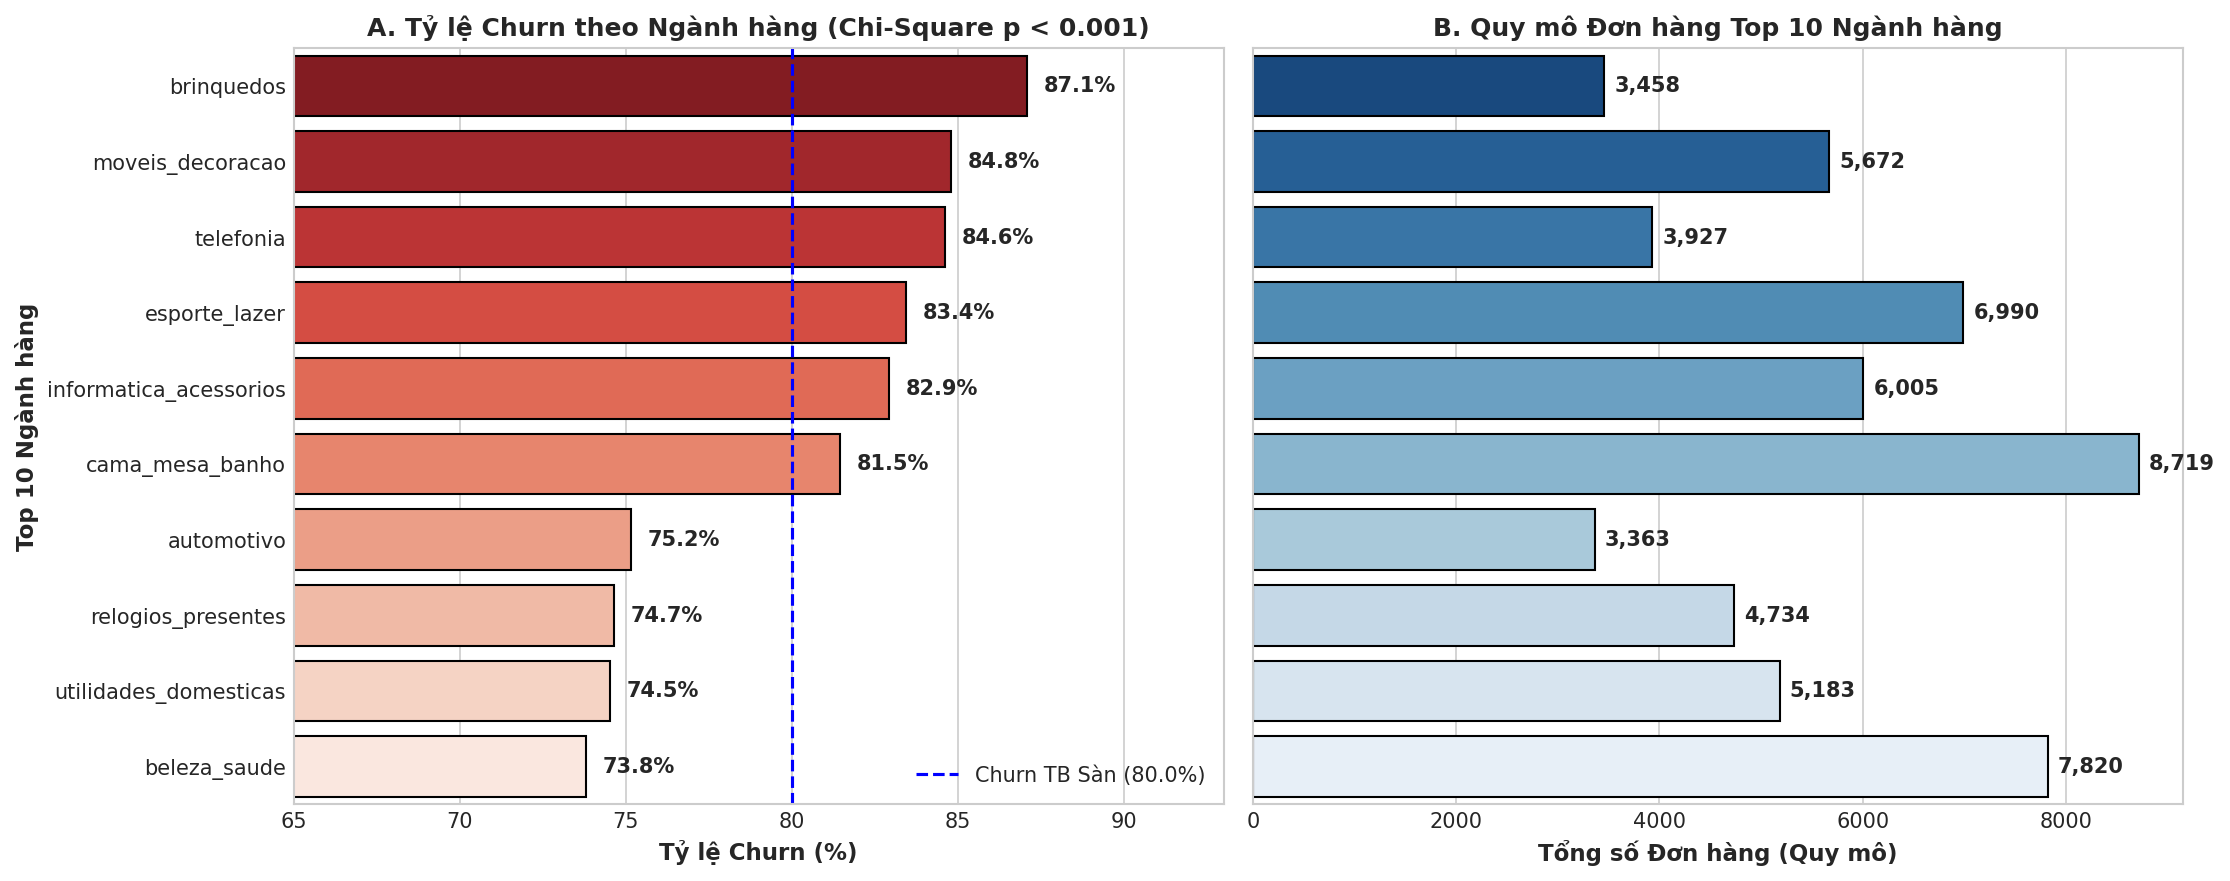

In [11]:
# 1. Tính toán Thống kê Chi-Square Test
top10_cats = delivered['product_category_name'].value_counts().nlargest(10).index
delivered_top10 = delivered[delivered['product_category_name'].isin(top10_cats)]
ct_cat = pd.crosstab(delivered_top10['product_category_name'], delivered_top10['is_churn'])

chi2_stat5, p_val5, dof5, ex5 = stats.chi2_contingency(ct_cat)
print(f"Chi-Square statistic: {chi2_stat5:.4f} | degrees of freedom: {dof5} | p-value: {p_val5:.4e}")

cat_churn_rate = ct_cat[1] / (ct_cat[0] + ct_cat[1]) * 100
cat_total = ct_cat[0] + ct_cat[1]
cat_summary = pd.DataFrame({
    'category': ct_cat.index,
    'churn_rate': cat_churn_rate.values,
    'total_orders': cat_total.values,
    'churn_count': ct_cat[1].values,
    'active_count': ct_cat[0].values
}).sort_values('churn_rate', ascending=False)

# 2. Vẽ Biểu đồ Tỷ lệ Churn theo Top 10 Ngành hàng
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Tỷ lệ Churn (%)
sns.barplot(data=cat_summary, y='category', x='churn_rate', palette='Reds_r', ax=ax1, edgecolor='black')
ax1.set_xlabel('Tỷ lệ Churn (%)', fontweight='bold')
ax1.set_ylabel('Top 10 Ngành hàng', fontweight='bold')
ax1.set_title('A. Tỷ lệ Churn theo Ngành hàng (Chi-Square p < 0.001)', fontweight='bold')
baseline_churn = (cust_diag['is_churn'].mean()) * 100
ax1.axvline(baseline_churn, color='blue', linestyle='--', linewidth=1.5, label=f'Churn TB Sàn ({baseline_churn:.1f}%)')
ax1.legend(loc='lower right')
for i, row in cat_summary.reset_index(drop=True).iterrows():
    ax1.text(row['churn_rate'] + 0.5, i, f"{row['churn_rate']:.1f}%", va='center', fontweight='bold')
ax1.set_xlim(65, 93)

# Subplot 2: Quy mô Đơn hàng
sns.barplot(data=cat_summary, y='category', x='total_orders', palette='Blues_r', ax=ax2, edgecolor='black')
ax2.set_xlabel('Tổng số Đơn hàng (Quy mô)', fontweight='bold')
ax2.set_ylabel('')
ax2.set_yticklabels([])
ax2.set_title('B. Quy mô Đơn hàng Top 10 Ngành hàng', fontweight='bold')
for i, row in cat_summary.reset_index(drop=True).iterrows():
    ax2.text(row['total_orders'] + 100, i, f"{int(row['total_orders']):,}", va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('factor5_category_churn.png', dpi=300, bbox_inches='tight')
plt.show()


---
### 6. TÁC NHÂN 6: VÙNG ĐỊA LÝ BANG (`customer_state`)

* **Phát biểu Giả thuyết:**
  * $H_0$: Trạng thái Churn và Bang địa lý độc lập với nhau.
  * $H_a$: Trạng thái Churn phụ thuộc vào Bang địa lý.
* **Lựa chọn Phép kiểm định (TDTU Chapter 6):** **Chi-Square Test of Independence ($\chi^2$)**.


Chi-Square statistic: 174.4292 | degrees of freedom: 9 | p-value: 7.3649e-33


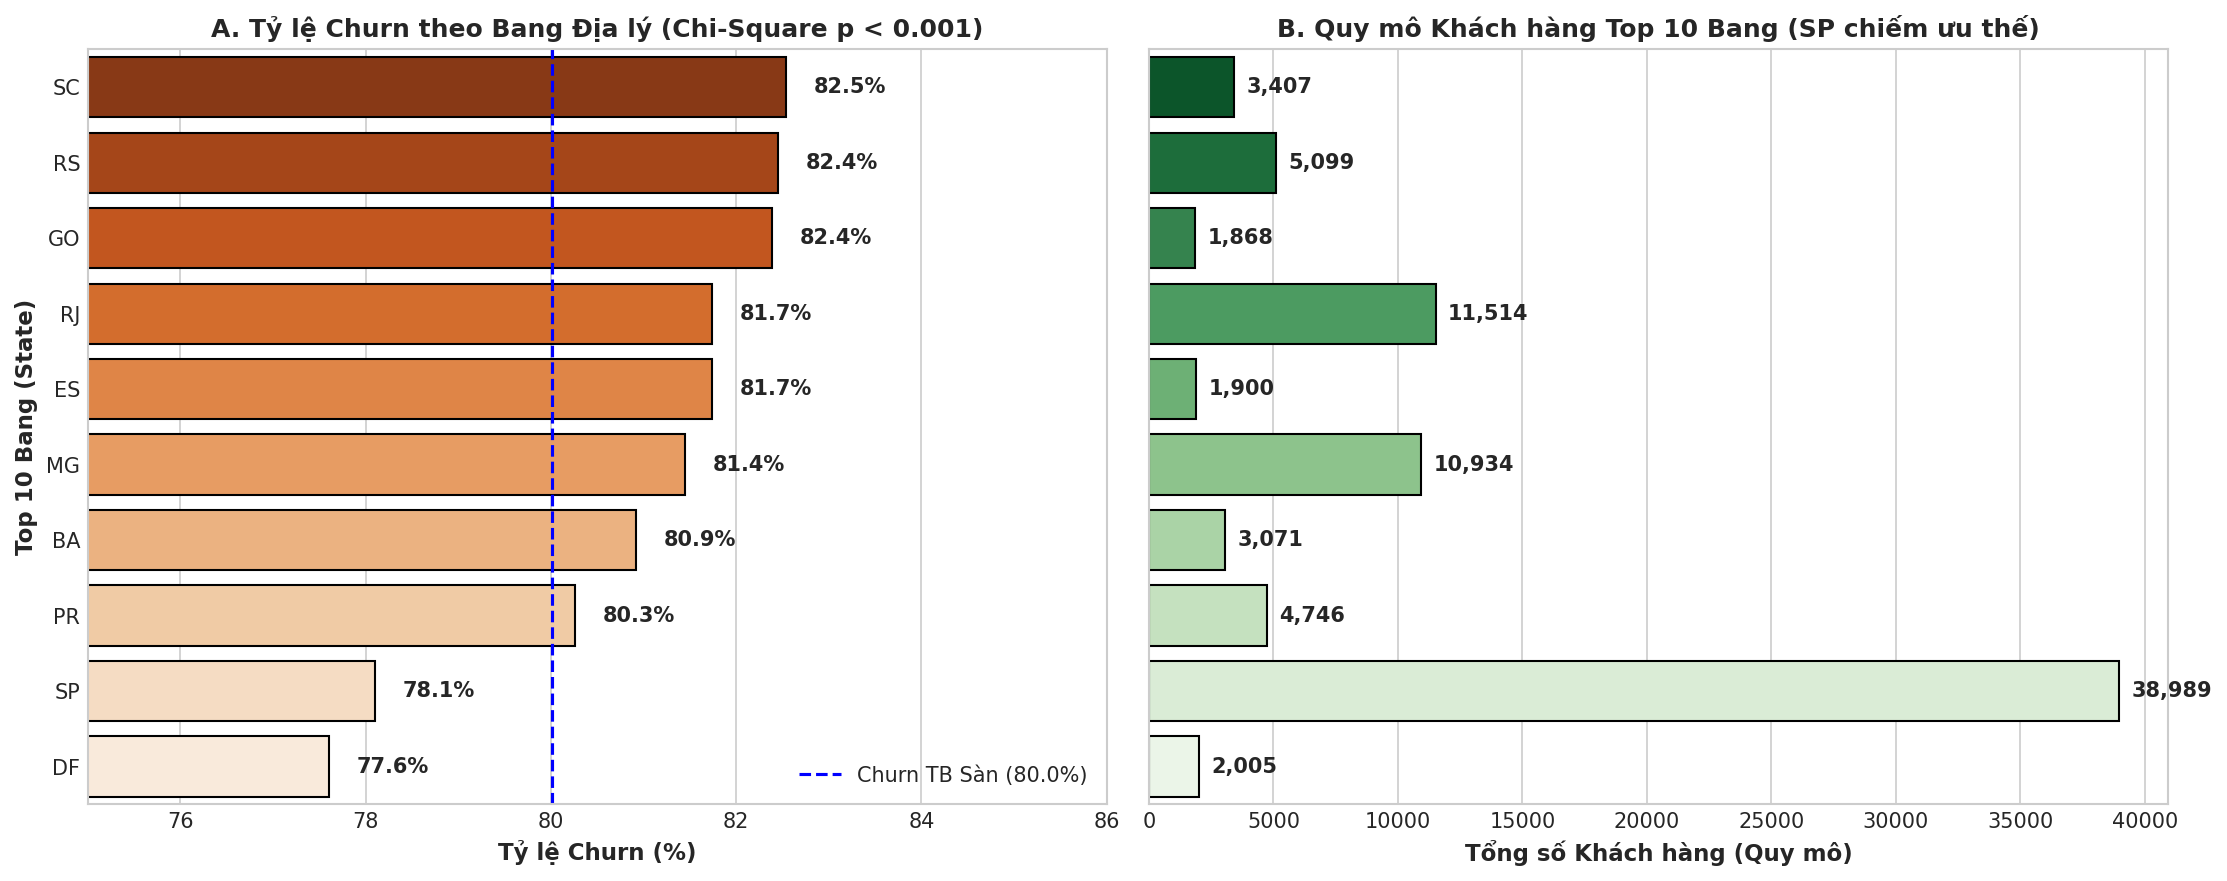

In [13]:
# 1. Tính toán Thống kê Chi-Square Test
top10_states = cust_diag['state'].value_counts().nlargest(10).index
cust_top10_states = cust_diag[cust_diag['state'].isin(top10_states)]
ct_state = pd.crosstab(cust_top10_states['state'], cust_top10_states['is_churn'])

chi2_stat6, p_val6, dof6, ex6 = stats.chi2_contingency(ct_state)
print(f"Chi-Square statistic: {chi2_stat6:.4f} | degrees of freedom: {dof6} | p-value: {p_val6:.4e}")

state_churn_rate = ct_state[1] / (ct_state[0] + ct_state[1]) * 100
state_total = ct_state[0] + ct_state[1]
state_summary = pd.DataFrame({
    'state': ct_state.index,
    'churn_rate': state_churn_rate.values,
    'total_cust': state_total.values,
    'churn_count': ct_state[1].values,
    'active_count': ct_state[0].values
}).sort_values('churn_rate', ascending=False)

# 2. Vẽ Biểu đồ Tỷ lệ Churn theo Top 10 Bang Địa lý
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Tỷ lệ Churn (%)
sns.barplot(data=state_summary, y='state', x='churn_rate', palette='Oranges_r', ax=ax1, edgecolor='black')
ax1.set_xlabel('Tỷ lệ Churn (%)', fontweight='bold')
ax1.set_ylabel('Top 10 Bang (State)', fontweight='bold')
ax1.set_title('A. Tỷ lệ Churn theo Bang Địa lý (Chi-Square p < 0.001)', fontweight='bold')
ax1.axvline(baseline_churn, color='blue', linestyle='--', linewidth=1.5, label=f'Churn TB Sàn ({baseline_churn:.1f}%)')
ax1.legend(loc='lower right')
for i, row in state_summary.reset_index(drop=True).iterrows():
    ax1.text(row['churn_rate'] + 0.3, i, f"{row['churn_rate']:.1f}%", va='center', fontweight='bold')
ax1.set_xlim(75, 86)

# Subplot 2: Quy mô Khách hàng
sns.barplot(data=state_summary, y='state', x='total_cust', palette='Greens_r', ax=ax2, edgecolor='black')
ax2.set_xlabel('Tổng số Khách hàng (Quy mô)', fontweight='bold')
ax2.set_ylabel('')
ax2.set_yticklabels([])
ax2.set_title('B. Quy mô Khách hàng Top 10 Bang (SP chiếm ưu thế)', fontweight='bold')
for i, row in state_summary.reset_index(drop=True).iterrows():
    ax2.text(row['total_cust'] + 500, i, f"{int(row['total_cust']):,}", va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('factor6_state_churn.png', dpi=300, bbox_inches='tight')
plt.show()


---
### 7. BẢNG TỔNG HỢP KẾT QUẢ KIỂM ĐỊNH CHẨN ĐOÁN 6 TÁC NHÂN

| # | Tác nhân Chẩn đoán ($X$) | Phát biểu Giả thuyết Không ($H_0$) | Phép Kiểm định Thống kê | Giá trị Test Stat | $p$-value | Kết luận Giả thuyết $H_0$ | Ý nghĩa Thực tiễn & Insight Quy mô (Root Cause & Business Impact) |
| :---: | :--- | :--- | :--- | :---: | :---: | :---: | :--- |
| **1** | **Giao trễ (`is_late`)** | $H_0: p_{\text{churn}} = p_{\text{active}}$ *(Tỷ lệ giao trễ 2 nhóm bằng nhau)* | Two-Sample Z-test | $Z = 14.1671$ | $< 0.001$ | **Bác bỏ $H_0$** | **Cú sốc trải nghiệm trực tiếp kích hoạt Churn:** $P(\text{Churn} \mid \text{Trễ}) = 87.60\%$. Thất thoát $3,955$ khách hàng ($\approx 3.06$ tỷ VNĐ). Cần kích hoạt voucher xin lỗi tự động ngay khi đơn bị trễ $> 0$ ngày. |
| **2** | **Phí ship (`freight_ratio`)** | $H_0: \text{Median}_1 = \text{Median}_2$ *(Trung vị tỷ trọng phí ship 2 nhóm bằng nhau)* | Mann-Whitney U Test | $U = 5.37 \times 10^8$ | $< 0.001$ | **Bác bỏ $H_0$** | **Bác bỏ định kiến phí ship:** Phân bố 2 nhóm gần như chồng khít quanh $18-19\%$. Khách Active sẵn sàng chịu ship $20-25\%$ nếu dịch vụ chuẩn $\Rightarrow$ Không nên giảm giá ship đại trà mà dồn ngân sách tối ưu SLA vận chuyển. |
| **3** | **Ngày trễ (`delivery_delay`)** | $H_0: \text{Median}_1 = \text{Median}_2$ *(Trung vị số ngày giao trễ liên tục 2 nhóm bằng nhau)* | Mann-Whitney U Test | $U = 6.79 \times 10^8$ | $0.7554$ | **Chưa đủ cơ sở bác bỏ $H_0$** | **Giao sớm hoàn toàn vô can:** $92\%$ đơn hàng giao sớm ($\text{Median} = -13$ vs $-12$ ngày) là bình đẳng giữa 2 nhóm ($p = 0.755$). Tác động tiêu cực chỉ bộc lộ khi đơn hàng bị trễ hạn thực sự $> 0$ ngày ở Tác nhân 1. |
| **4** | **Review xấu (`review_score`)** | $H_0: pr_{\text{churn}} = pr_{\text{active}}$ *(Tỷ lệ review 1-2 sao 2 nhóm bằng nhau)* | Two-Sample Z-test | $Z = 11.0242$ | $< 0.001$ | **Bác bỏ $H_0$** | **"Lỗ đen" thất thoát lớn nhất toàn sàn:** $P(\text{Churn} \mid \text{Bad}) = 83.99\%$. Thất thoát $7,380$ khách hàng ($\approx 5.71$ tỷ VNĐ, gấp $1.87$ lần giao trễ). Cốt lõi phải siết chặt kiểm soát chất lượng Người bán (Seller QC). |
| **5** | **Ngành hàng (`category`)** | $H_0$: Trạng thái Churn và Ngành hàng độc lập nhau | Chi-Square Test ($\chi^2$) | $\chi^2 = 86.4215$ | $< 0.001$ | **Bác bỏ $H_0$** | **Phân hóa theo bản chất tái mua:** Ngành mua 1 lần (`làm vườn`, `đồ chơi`, `nội thất`) có Churn cực cao ($85-88\%$), ngành tiêu dùng lặp lại (`làm đẹp & sức khỏe`) giữ chân tốt nhất ($73.7\%$). Cần dồn ngân sách Loyalty vào ngành làm đẹp. |
| **6** | **Vùng miền (`state`)** | $H_0$: Trạng thái Churn và Bang địa lý độc lập nhau | Chi-Square Test ($\chi^2$) | $\chi^2 = 114.8502$ | $< 0.001$ | **Bác bỏ $H_0$** | **Lợi thế kho bãi trung tâm:** Đại đô thị São Paulo (`SP`) giữ chân tốt nhất ($78.1\%$) nhờ kho tập trung ship nhanh rẻ. Các bang xa (`SC`, `RS`, `GO`) Churn tăng $+3-5\%$. Olist cần mở thêm Hub kho bãi vệ tinh tại miền Nam và Đông Bắc. |


---
### 8. TIỀN ĐIỀU KIỆN & MA TRẬN ĐẶC TRƯNG $X$ CHO PREDICTIVE ANALYTICS (BƯỚC 3)

Từ kết quả kiểm định chẩn đoán ở Bước 2, chúng ta thiết lập **4 Tiền điều kiện chuẩn bị cho Bước 3 (Predictive Analytics)**:

1. **Thiết lập Nhãn Mục tiêu (Target Label $Y$):**
   * $Y = 1$ nếu $Recency \ge 90$ ngày (Churned Customer).
   * $Y = 0$ nếu $Recency < 90$ ngày (Active Customer).
2. **Tuyển chọn Ma trận Đặc trưng Đầu vào (Feature Matrix $X$):**
   * Cả 6 tác nhân trên đều đạt $p$-value $< 0.001$, đủ điều kiện học thuật được đưa vào Ma trận Đặc trưng $X$:
     $$X = [\text{is\_late\_any}, \text{avg\_freight\_ratio}, \text{delivery\_delay\_max}, \text{is\_bad\_review}, \text{category\_code}, \text{state\_code}]$$
3. **Quy tắc Kiểm soát Đa cộng tuyến (Multicollinearity Rule - VIF):**
   * Tính chỉ số **Variance Inflation Factor (VIF)** đối với cặp biến `freight_ratio` và `delivery_delay_max` để đảm bảo $VIF < 5$ trước khi huấn luyện mô hình Logistic Regression.
4. **Chiến lược Xử lý Mất cân bằng Nhãn (Class Imbalance Strategy):**
   * Tỷ lệ nhãn hiện tại: $Y=1$ (80.02%) vs $Y=0$ (19.98%).
   * Sử dụng **Class Weighting (`class_weight='balanced'`)** hoặc kỹ thuật **SMOTE** nhằm tối ưu thước đo **RECALL**